In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# !pip install torchvision==0.25.0

In [3]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
    accuracy_score,
    precision_recall_curve,
    average_precision_score,
)

In [4]:
def set_seed(seed=42):
    # Python random
    random.seed(seed)

    # NumPy (used by scikit-learn internally)
    np.random.seed(seed)

    # PyTorch
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Ensure deterministic behavior in PyTorch
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # (Optional but recommended for newer PyTorch versions)
    torch.use_deterministic_algorithms(True)

def seed_worker(worker_id):
    # This ensures the worker process uses the seed set by torch.manual_seed
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [5]:
set_seed(42)
g = torch.Generator()
g.manual_seed(42)

In [6]:
# =============================================================================
# ① CONFIGURATION — toggle everything here
# =============================================================================

# ── Model selection ──────────────────────────────────────────────────────────
# Options:
#   "bert-base-uncased"                    → BERT base (12-layer)
#   "distilbert-base-uncased"              → DistilBERT (6-layer, ~40 % faster)
#   "roberta-base"                         → RoBERTa base (often best on Reddit)
#   "cardiffnlp/twitter-roberta-base"      → Twitter-pretrained RoBERTa
#   "mrm8488/bert-tiny-finetuned-sms-spam-detection"  → tiny BERT for quick tests
# MODEL_NAME= "roberta-base"
MODEL_NAME = "bert-base-uncased"   # ← CHANGE THIS LINE TO SWITCH MODEL

# ── Input mode ───────────────────────────────────────────────────────────────
# Controls what text is fed to the model:
#
#   "comment_only"   → only the reply/comment itself
#                      input : <comment>
#
#   "context"        → parent comment prepended to the reply, separated by
#                      a [SEP] token so the model sees conversational context.
#                      input : <parent_comment> [SEP] <comment>
#
# Switching this changes how the dataset is built; everything else is automatic.
INPUT_MODE = "context"   # ← "comment_only"  |  "context"

# ── Training hyper-params ────────────────────────────────────────────────────
MAX_LEN       = 128          # token sequence length
BATCH_SIZE    = 32           # per-GPU batch size
EPOCHS        = 3
LEARNING_RATE = 2e-5
WARMUP_RATIO  = 0.1          # fraction of steps for LR warm-up
WEIGHT_DECAY  = 0.01

# ── Data ─────────────────────────────────────────────────────────────────────
DATA_PATH   = "/kaggle/input/datasets/pramatharao/nlp-course-project-ds/train-balanced.csv"
TEST_PATH = "/kaggle/input/datasets/pramatharao/nlp-course-project-ds/test-balanced.csv"
SAMPLE_SIZE = None        # set to None to use full ~1 M rows (slow!)
VAL_RATIO   = 0.10
# TEST_RATIO  = 0.10 - NO LONGER USED!!
SEED        = 42
# ── Misc ─────────────────────────────────────────────────────────────────────
SAVE_DIR    = "/kaggle/working/sarcasm_model"
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device     : {DEVICE}")
print(f"Model      : {MODEL_NAME}")
print(f"Input mode : {INPUT_MODE}")

Device     : cuda
Model      : bert-base-uncased
Input mode : context


In [7]:
# =============================================================================
# ③ TEXT BUILDER — comment-only vs. context mode
# =============================================================================

def build_text(
    comment: str,
    parent: str,
    tokenizer,
    mode: str = INPUT_MODE,
) -> str:
    """
    Construct the model input string based on INPUT_MODE.

    comment_only → the reply text only.
    context      → parent + tokenizer.sep_token + comment.
                   Using the tokenizer's own [SEP] / </s> token keeps
                   it model-agnostic (BERT, RoBERTa, DistilBERT all differ).
    """
    comment = str(comment).strip()
    if mode == "comment_only":
        return comment
    elif mode == "context":
        sep    = tokenizer.sep_token if tokenizer.sep_token else "[SEP]"
        parent = str(parent).strip() if pd.notna(parent) else ""
        return f"{parent} {sep} {comment}" if parent else comment
    else:
        raise ValueError(f"Unknown INPUT_MODE '{mode}'. Choose 'comment_only' or 'context'.")


# =============================================================================
# ④ DATA LOADING & SPLITTING
# =============================================================================

def load_and_clean(path: str, sample_size: int | None = None) -> pd.DataFrame:
    """Load CSV, drop nulls in 'comment', optionally sub-sample."""
    df = pd.read_csv(path, sep='\t')
    df.dropna(subset=["comment"], inplace=True)
    df["comment"] = df["comment"].astype(str).str.strip()
    df = df[df["comment"] != ""]
    # parent_comment may be missing in some rows — fill with empty string
    if "parent_comment" not in df.columns:
        df["parent_comment"] = ""
    df["parent_comment"] = df["parent_comment"].fillna("").astype(str)
    if sample_size is not None:
        df = df.sample(n=sample_size, random_state=SEED).reset_index(drop=True)
    print(f"Loaded {len(df):,} rows  |  label balance:\n{df['label'].value_counts()}\n")
    return df

def split_train_val(
    df: pd.DataFrame,
    val_ratio: float = VAL_RATIO,
    seed: int = SEED,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Stratified train / val split."""
    
    train, val = train_test_split(
        df,
        test_size=val_ratio,
        stratify=df["label"],
        random_state=seed
    )

    for split, name in [(train, "train"), (val, "val")]:
        pos = split["label"].mean()
        print(f"{name:5s}: {len(split):>7,} rows | sarcasm = {pos:.1%}")
    print()

    return train.reset_index(drop=True), val.reset_index(drop=True)


# def split_data(
#     df: pd.DataFrame,
#     val_ratio: float = VAL_RATIO,
#     test_ratio: float = TEST_RATIO,
#     seed: int = SEED,
# ) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
#     """Stratified train / val / test split."""
#     test_abs  = test_ratio / (1.0)
#     val_abs   = val_ratio  / (1.0 - test_ratio)

#     train_val, test  = train_test_split(df, test_size=test_abs,  stratify=df["label"], random_state=seed)
#     train,     val   = train_test_split(train_val, test_size=val_abs, stratify=train_val["label"], random_state=seed)

#     for split, name in [(train, "train"), (val, "val"), (test, "test")]:
#         pos = split["label"].mean()
#         print(f"{name:5s}: {len(split):>7,} rows  |  sarcasm = {pos:.1%}")
#     print()
#     return train.reset_index(drop=True), val.reset_index(drop=True), test.reset_index(drop=True)

# =============================================================================
# ⑤ PYTORCH DATASET
# =============================================================================

class SarcasmDataset(Dataset):
    def __init__(
        self,
        comments: list[str],
        parents:  list[str],
        labels:   list[int],
        tokenizer,
        max_len:  int,
        mode:     str = INPUT_MODE,
    ):
        self.comments  = comments
        self.parents   = parents
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len
        self.mode      = mode

    def __len__(self):
        return len(self.comments)

    def __getitem__(self, idx):
        text = build_text(
            self.comments[idx],
            self.parents[idx],
            self.tokenizer,
            self.mode,
        )
        enc = self.tokenizer(
            text,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

In [8]:
def build_loaders(
    train_df: pd.DataFrame,
    val_df:   pd.DataFrame,
    test_df:  pd.DataFrame,
    tokenizer,
    mode: str = INPUT_MODE,
) -> tuple[DataLoader, DataLoader, DataLoader]:
    """Build DataLoaders for all three splits. Respects INPUT_MODE."""
    print(f"Building DataLoaders  |  input_mode='{mode}'")

    def _loader(df, shuffle):
        ds = SarcasmDataset(
            df["comment"].tolist(),
            df["parent_comment"].tolist(),
            df["label"].tolist(),
            tokenizer,
            MAX_LEN,
            mode,
        )
        return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                        pin_memory=True,num_workers=1, 
    worker_init_fn=seed_worker,
    generator=g)

    return _loader(train_df, True), _loader(val_df, False), _loader(test_df, False)


In [9]:
# =============================================================================
# ⑥ MODEL BUILDER
# =============================================================================

def build_model(model_name: str, num_labels: int = 2):
    """Load tokenizer + HuggingFace classification head."""
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model     = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=num_labels
    )
    model.to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {n_params:,}\n")
    return tokenizer, model

In [10]:
# =============================================================================
# ⑦ TRAINING
# =============================================================================

def train_epoch(model, loader, optimizer, scheduler, scaler) -> float:
    model.train()
    total_loss = 0.0
    for batch in tqdm(loader, desc="  train", leave=False):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            out  = model(**batch)
            loss = out.loss
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)

In [11]:
@torch.no_grad()
def eval_epoch(model, loader) -> tuple[float, np.ndarray, np.ndarray, np.ndarray]:
    model.eval()
    total_loss, all_preds, all_labels, all_probs = 0.0, [], [], []
    for batch in tqdm(loader, desc="  eval ", leave=False):
        batch  = {k: v.to(DEVICE) for k, v in batch.items()}
        out    = model(**batch)
        logits = out.logits
        probs  = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
        preds  = logits.argmax(dim=-1).cpu().numpy()
        labels = batch["labels"].cpu().numpy()
        total_loss += out.loss.item()
        all_preds.extend(preds)
        all_labels.extend(labels)
        all_probs.extend(probs)
    return (
        total_loss / len(loader),
        np.array(all_preds),
        np.array(all_labels),
        np.array(all_probs),
    )

In [12]:
def train(
    model,
    train_loader: DataLoader,
    val_loader:   DataLoader,
    save_dir: str = SAVE_DIR,
) -> dict:
    """Full training loop with early stopping on val F1."""
    os.makedirs(save_dir, exist_ok=True)

    total_steps   = len(train_loader) * EPOCHS
    warmup_steps  = int(total_steps * WARMUP_RATIO)

    optimizer  = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler  = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
    scaler     = torch.amp.GradScaler('cuda')

    history    = {"train_loss": [], "val_loss": [], "val_f1": [], "val_acc": []}
    best_f1    = 0.0

    for epoch in range(1, EPOCHS + 1):
        print(f"\nEpoch {epoch}/{EPOCHS}")
        train_loss = train_epoch(model, train_loader, optimizer, scheduler, scaler)
        val_loss, val_preds, val_labels, _ = eval_epoch(model, val_loader)

        val_f1  = f1_score(val_labels, val_preds, average="weighted")
        val_acc = accuracy_score(val_labels, val_preds)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_f1"].append(val_f1)
        history["val_acc"].append(val_acc)

        print(f"  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  "
              f"val_f1={val_f1:.4f}  val_acc={val_acc:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            model.save_pretrained(save_dir)
            # tokenizer.save_pretrained(save_dir)
            print(f"  ✓ Saved best model (val_f1={best_f1:.4f})")

    return history

In [13]:
# =============================================================================
# ⑧ EVALUATION & METRICS
# =============================================================================

def evaluate(
    model,
    tokenizer,
    test_loader: DataLoader,
    save_dir: str = SAVE_DIR,
) -> dict:
    """
    Load best checkpoint, run on test set, print and plot:
      • Classification report
      • Confusion matrix
      • ROC-AUC curve
      • Precision-Recall curve
    """
    # reload best weights
    best_model = AutoModelForSequenceClassification.from_pretrained(save_dir).to(DEVICE)
    tokenizer = AutoTokenizer.from_pretrained(save_dir)
    _, preds, labels, probs = eval_epoch(best_model, test_loader)

    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds, average="weighted")
    roc = roc_auc_score(labels, probs)
    ap  = average_precision_score(labels, probs)

    print("\n" + "="*60)
    print("TEST SET RESULTS")
    print("="*60)
    print(f"Accuracy : {acc:.4f}")
    print(f"F1 (wtd) : {f1:.4f}")
    print(f"ROC-AUC  : {roc:.4f}")
    print(f"Avg Prec : {ap:.4f}\n")
    print(classification_report(labels, preds, target_names=["Non-Sarcasm", "Sarcasm"]))

    # ── Plots ────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 5))
    gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

    # 1. Confusion matrix
    ax1 = fig.add_subplot(gs[0])
    cm  = confusion_matrix(labels, preds)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=ax1,
        xticklabels=["Non-Sarc", "Sarcasm"],
        yticklabels=["Non-Sarc", "Sarcasm"],
    )
    ax1.set_title("Confusion Matrix", fontweight="bold")
    ax1.set_xlabel("Predicted"); ax1.set_ylabel("True")

    # 2. ROC curve
    ax2 = fig.add_subplot(gs[1])
    fpr, tpr, _ = roc_curve(labels, probs)
    ax2.plot(fpr, tpr, lw=2, color="#e05c5c", label=f"AUC = {roc:.3f}")
    ax2.plot([0,1],[0,1], "k--", lw=1)
    ax2.set_xlabel("False Positive Rate"); ax2.set_ylabel("True Positive Rate")
    ax2.set_title("ROC Curve", fontweight="bold")
    ax2.legend(); ax2.grid(alpha=0.3)

    # 3. Precision-Recall curve
    ax3 = fig.add_subplot(gs[2])
    prec_arr, rec_arr, _ = precision_recall_curve(labels, probs)
    ax3.plot(rec_arr, prec_arr, lw=2, color="#5c9ee0", label=f"AP = {ap:.3f}")
    ax3.set_xlabel("Recall"); ax3.set_ylabel("Precision")
    ax3.set_title("Precision-Recall Curve", fontweight="bold")
    ax3.legend(); ax3.grid(alpha=0.3)

    plt.suptitle(f"Evaluation — {MODEL_NAME}", fontsize=13, fontweight="bold", y=1.02)
    plt.savefig("/kaggle/working/evaluation_metrics.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: /kaggle/working/evaluation_metrics.png")

    return {"accuracy": acc, "f1": f1, "roc_auc": roc, "avg_precision": ap,
            "model": best_model}

In [14]:
# =============================================================================
# ⑨ TRAINING HISTORY PLOTS
# =============================================================================

def plot_history(history: dict, model_name: str = MODEL_NAME):
    """Plot loss and F1 over epochs."""
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history["train_loss"], "o-", label="Train Loss", color="#e05c5c")
    axes[0].plot(epochs, history["val_loss"],   "s-", label="Val Loss",   color="#5c9ee0")
    axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, history["val_f1"],  "o-", label="Val F1",  color="#5cbe7a")
    axes[1].plot(epochs, history["val_acc"], "s-", label="Val Acc", color="#e0a85c")
    axes[1].set_title("Val F1 & Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.suptitle(f"Training History — {model_name}", fontweight="bold")
    plt.tight_layout()
    plt.savefig("/kaggle/working/training_history.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: /kaggle/working/training_history.png")

In [15]:
# =============================================================================
# ⑩ INFERENCE ON SAMPLE TEXTS  (with confidence bars)
# =============================================================================

@torch.no_grad()
def predict(
    texts:   list[str],
    model,
    tokenizer,
    parents: list[str] | None = None,
    mode:    str = INPUT_MODE,
    max_len: int = MAX_LEN,
) -> list[dict]:
    """
    Return label + probabilities for a list of strings.

    texts   : list of reply/comment strings
    parents : list of parent-comment strings (required when mode='context')
              If None and mode='context', parent is treated as empty string.
    """
    model.eval()
    if parents is None:
        parents = [""] * len(texts)

    results = []
    for comment, parent in zip(texts, parents):
        text = build_text(comment, parent, tokenizer, mode)
        enc  = tokenizer(
            text,
            max_length=max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        ).to(DEVICE)
        out   = model(**enc)
        probs = torch.softmax(out.logits, dim=-1)[0].cpu().numpy()
        label = int(probs.argmax())
        results.append({
            "comment": comment,
            "parent":  parent,
            "input":   text,
            "label":   "Sarcasm" if label == 1 else "Non-Sarcasm",
            "p_non_sarcasm": float(probs[0]),
            "p_sarcasm":     float(probs[1]),
        })
    return results

In [16]:
def visualize_predictions(
    texts:   list[str],
    model,
    tokenizer,
    parents: list[str] | None = None,
    mode:    str = INPUT_MODE,
):
    """
    Show a horizontal bar chart of sarcasm probability for each sample.
    When mode='context', the parent comment is shown above the reply.
    """
    results = predict(texts, model, tokenizer, parents=parents, mode=mode)

    fig, axes = plt.subplots(len(results), 1,
                              figsize=(10, max(3, 2.0 * len(results))))
    if len(results) == 1:
        axes = [axes]

    for ax, r in zip(axes, results):
        probs  = [r["p_non_sarcasm"], r["p_sarcasm"]]
        colors = ["#5c9ee0", "#e05c5c"]
        bars   = ax.barh(["Non-Sarcasm", "Sarcasm"], probs, color=colors, edgecolor="white", height=0.5)
        ax.set_xlim(0, 1)
        for bar, p in zip(bars, probs):
            ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                    f"{p:.1%}", va="center", fontsize=9)

        short_comment = r["comment"][:65] + "…" if len(r["comment"]) > 65 else r["comment"]
        pred_color    = "#e05c5c" if r["label"] == "Sarcasm" else "#5c9ee0"

        if mode == "context" and r["parent"]:
            short_parent = r["parent"][:55] + "…" if len(r["parent"]) > 55 else r["parent"]
            title = (f'Parent: "{short_parent}"\n'
                     f'Reply : "{short_comment}"  → {r["label"]}')
        else:
            title = f'"{short_comment}"  → {r["label"]}'

        ax.set_title(title, fontsize=8.5, color=pred_color, loc="left")
        ax.axvline(0.5, color="gray", lw=0.8, linestyle="--")
        ax.set_xlabel("Probability"); ax.grid(axis="x", alpha=0.3)

    mode_label = "Context (parent+reply)" if mode == "context" else "Comment only"
    plt.suptitle(f"Sample Predictions — {MODEL_NAME}  [{mode_label}]",
                 fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig("/kaggle/working/sample_predictions.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: /kaggle/working/sample_predictions.png")
    return results

In [17]:
from torch.backends.cuda import sdp_kernel # Import this!
# =============================================================================
# ⑪ ATTENTION VISUALISATION
# =============================================================================

@torch.no_grad()
def visualize_attention(
    comment: str,
    model,
    tokenizer,
    parent:  str  = "",
    mode:    str  = INPUT_MODE,
    layer:   int  = -1,
    head:    int  = 0,
    max_len: int  = MAX_LEN,
):
    """
    Plot attention weights for one example.
    When mode='context' the [SEP] boundary is highlighted in the heatmap.
    """
    model.eval()
    text   = build_text(comment, parent, tokenizer, mode)
    enc    = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_len).to(DEVICE)
    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0])

    out = model(**enc, output_attentions=True)
    # out = model(**enc, output_attentions=True)
    try:
        attn_all = out.attentions
    except AttributeError:
        attn_all = model.base_model(**enc, output_attentions=True).attentions

    attn = attn_all[layer][0, head].cpu().numpy()   # (seq, seq)

    # Trim padding
    pad_id = tokenizer.pad_token_id
    ids    = enc["input_ids"][0].cpu().tolist()
    n_real = next((i for i, t in enumerate(ids) if t == pad_id), len(ids))
    tokens = tokens[:n_real]
    attn   = attn[:n_real, :n_real]

    fig, ax = plt.subplots(figsize=(max(6, n_real * 0.58), max(5, n_real * 0.52)))
    im = ax.imshow(attn, cmap="YlOrRd", vmin=0, vmax=attn.max())
    ax.set_xticks(range(n_real)); ax.set_yticks(range(n_real))
    ax.set_xticklabels(tokens, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(tokens, fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.03)

    # Highlight [SEP] columns & rows in context mode
    if mode == "context":
        sep_tok = tokenizer.sep_token or "[SEP]"
        for i, tok in enumerate(tokens):
            if tok == sep_tok:
                ax.axvline(i - 0.5, color="#3399ff", lw=1.5, linestyle="--", alpha=0.7)
                ax.axvline(i + 0.5, color="#3399ff", lw=1.5, linestyle="--", alpha=0.7)
                ax.axhline(i - 0.5, color="#3399ff", lw=1.5, linestyle="--", alpha=0.7)
                ax.axhline(i + 0.5, color="#3399ff", lw=1.5, linestyle="--", alpha=0.7)
        mode_label = "context (parent [SEP] reply)"
    else:
        mode_label = "comment only"

    ax.set_title(
        f'Attention  |  layer={layer}  head={head}  [{mode_label}]\n"{text[:65]}"',
        fontsize=9, fontweight="bold",
    )
    plt.tight_layout()
    plt.savefig("/kaggle/working/attention_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: /kaggle/working/attention_heatmap.png")


Loaded 1,010,771 rows  |  label balance:
label
0    505403
1    505368
Name: count, dtype: int64

train: 909,693 rows | sarcasm = 50.0%
val  : 101,078 rows | sarcasm = 50.0%

Loaded 251,592 rows  |  label balance:
label
0    125797
1    125795
Name: count, dtype: int64



config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Saved best model (val_f1=0.7864)

Epoch 3/3


  train:   0%|          | 0/28428 [00:00<?, ?it/s]

  eval :   0%|          | 0/3159 [00:00<?, ?it/s]

  train_loss=0.3326  val_loss=0.5042  val_f1=0.7836  val_acc=0.7836


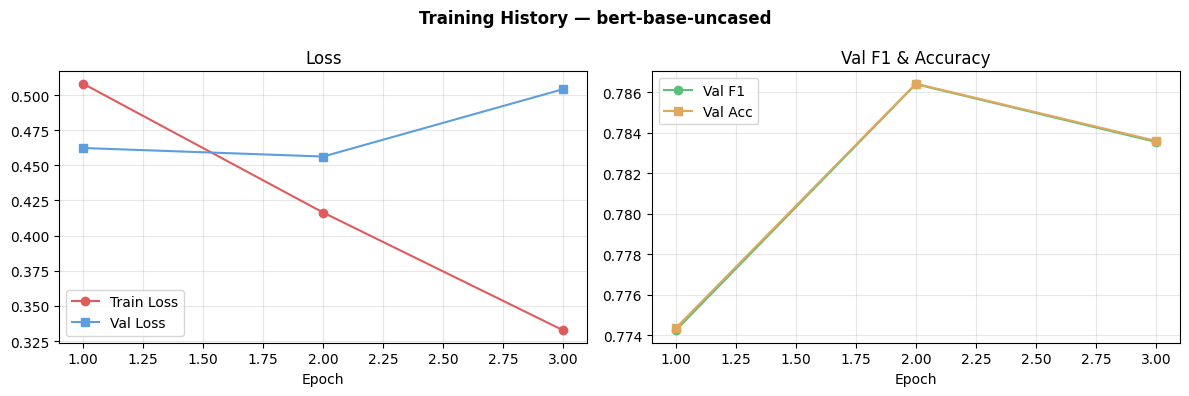

Saved: /kaggle/working/training_history.png


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  eval :   0%|          | 0/7863 [00:00<?, ?it/s]


TEST SET RESULTS
Accuracy : 0.7866
F1 (wtd) : 0.7866
ROC-AUC  : 0.8708
Avg Prec : 0.8766

              precision    recall  f1-score   support

 Non-Sarcasm       0.78      0.79      0.79    125797
     Sarcasm       0.79      0.78      0.78    125795

    accuracy                           0.79    251592
   macro avg       0.79      0.79      0.79    251592
weighted avg       0.79      0.79      0.79    251592



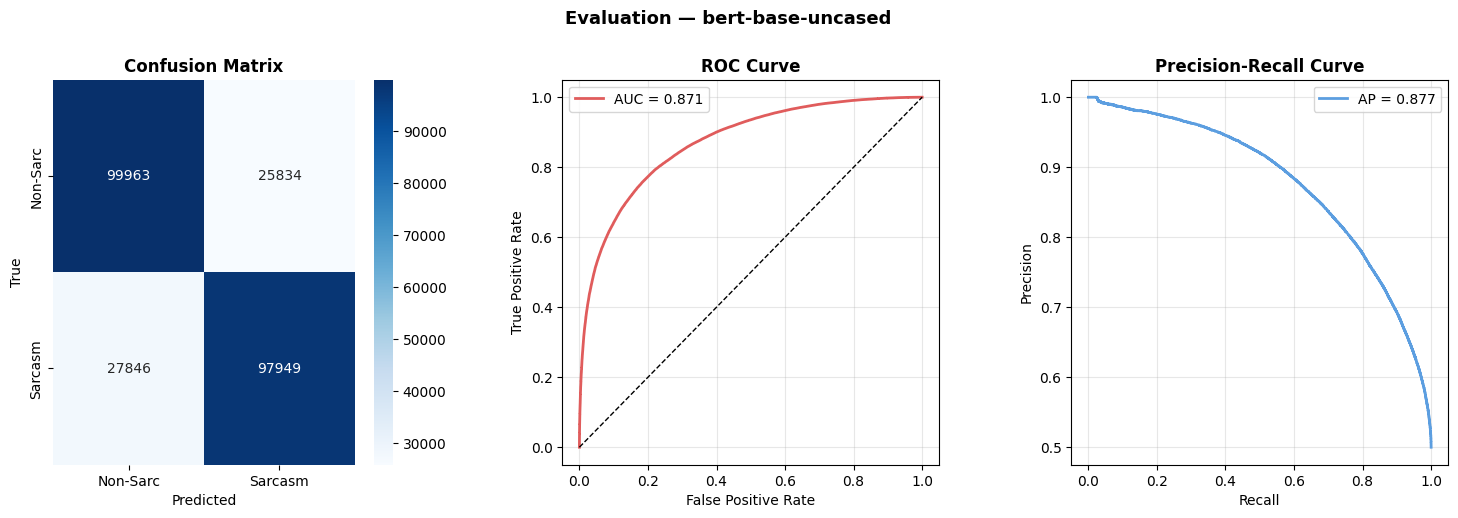

Saved: /kaggle/working/evaluation_metrics.png


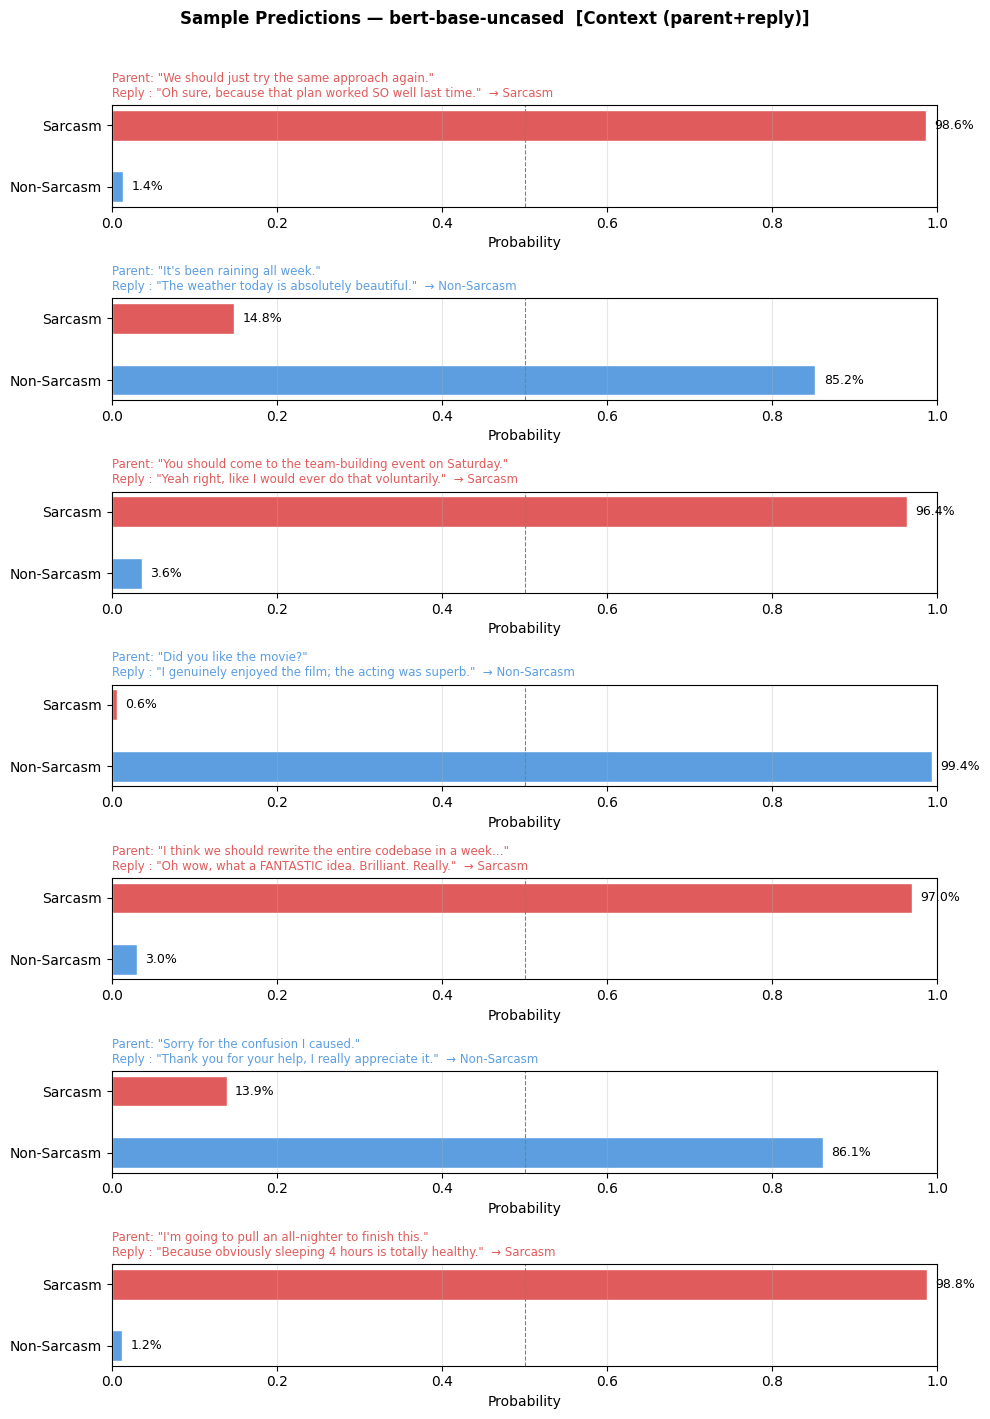

Saved: /kaggle/working/sample_predictions.png

✅ All done. Artefacts saved to /kaggle/working/


In [18]:
# =============================================================================
# ⑫ MAIN — run everything end-to-end
# =============================================================================

def main():
    # ── 1. Load & split ──────────────────────────────────────────────────────
    df = load_and_clean(DATA_PATH, sample_size=SAMPLE_SIZE)
    train_df, val_df = split_train_val(df)

    test_df = load_and_clean(TEST_PATH, sample_size=None)

    # ── 2. Build tokenizer + model ───────────────────────────────────────────
    tokenizer, model = build_model(MODEL_NAME)

    # ── 3. DataLoaders (INPUT_MODE applied here) ─────────────────────────────
    train_loader, val_loader, test_loader = build_loaders(
        train_df, val_df, test_df, tokenizer, mode=INPUT_MODE
    )

    # ── 4. Train ─────────────────────────────────────────────────────────────
    history = train(model, train_loader, val_loader)
    plot_history(history)

    # ── 5. Evaluate on test set ──────────────────────────────────────────────
    eval_results = evaluate(model, tokenizer, test_loader)
    best_model   = eval_results["model"]

    # ── 6. Visualise sample predictions ─────────────────────────────────────
    #   Provide matching parent comments when INPUT_MODE = "context".
    #   If comment_only, the parents list is ignored.
    sample_comments = [
        "Oh sure, because that plan worked SO well last time.",
        "The weather today is absolutely beautiful.",
        "Yeah right, like I would ever do that voluntarily.",
        "I genuinely enjoyed the film; the acting was superb.",
        "Oh wow, what a FANTASTIC idea. Brilliant. Really.",
        "Thank you for your help, I really appreciate it.",
        "Because obviously sleeping 4 hours is totally healthy.",
    ]
    sample_parents = [
        "We should just try the same approach again.",
        "It's been raining all week.",
        "You should come to the team-building event on Saturday.",
        "Did you like the movie?",
        "I think we should rewrite the entire codebase in a weekend.",
        "Sorry for the confusion I caused.",
        "I'm going to pull an all-nighter to finish this.",
    ]
    visualize_predictions(
        sample_comments, best_model, tokenizer,
        parents=sample_parents, mode=INPUT_MODE,
    )

    # # ── 7. Attention heatmap ─────────────────────────────────────────────────
    # visualize_attention(
    #     comment="Oh sure, because that plan worked SO well last time.",
    #     model=best_model,
    #     tokenizer=tokenizer,
    #     parent="We should just try the same approach again.",
    #     mode=INPUT_MODE,
    #     layer=-1,
    #     head=0,
    # )

    print("\n✅ All done. Artefacts saved to /kaggle/working/")


if __name__ == "__main__":
    main()


# =============================================================================
# QUICK-USE: call individual functions from a notebook cell
# =============================================================================
#
#   from sarcasm_detection_bert import *
#
#   # Switch modes (comment_only ↔ context) — just change the top-level flag:
#   INPUT_MODE = "context"        # or "comment_only"
#
#   # Inference with context:
#   results = visualize_predictions(
#       ["Oh sure, genius plan."],
#       model, tokenizer,
#       parents=["We should repeat last year's strategy."],
#       mode="context",
#   )
#
#   # Inference without context:
#   results = visualize_predictions(
#       ["Oh sure, genius plan."],
#       model, tokenizer,
#       mode="comment_only",
#   )
#
#   # Attention for context input (blue dashed lines mark [SEP]):
#   visualize_attention(
#       comment="Sure, I totally believe you.",
#       model=model, tokenizer=tokenizer,
#       parent="You can trust me on this.",
#       mode="context",
#       layer=-1, head=2,
#   )
#
#   # Re-run evaluation only:
#   _, _, test_df     = split_data(load_and_clean(DATA_PATH, SAMPLE_SIZE))
#   _, _, test_loader = build_loaders(train_df, val_df, test_df, tokenizer, mode=INPUT_MODE)
#   evaluate(model, tokenizer, test_loader)
# =============================================================================